In [1]:
import pandas as pd 
import numpy as np 
from sklearn.impute import SimpleImputer

In [2]:
df = pd.read_csv('iris.csv')

In [3]:
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [4]:
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [5]:
#reset 
df = pd.read_csv('iris.csv')

#generate random locations
import random

cells = []

for i in range(5):
    row = random.randint(0,149)
    column = random.randint(0, 3)
    cells.append((row, column))

for cell in cells:
    df.iloc[cell[0], cell[1]] = np.nan

df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    5
petal_width     0
species         0
dtype: int64

In [6]:
imputer = SimpleImputer(strategy='mean')
col = df.columns
for i in range(len(col) - 1):
    df[col[i]] = imputer.fit_transform(df[[col[i]]])

df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

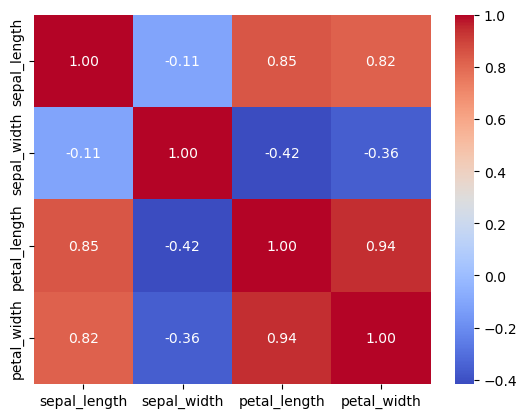

In [7]:
import matplotlib.pyplot as plt 
import seaborn as sns
corr = df.drop(columns = ['species']).corr()

sns.heatmap(corr, annot = True, cmap='coolwarm', fmt='.2f')
plt.show()